In [1]:
import dotenv
import os

In [2]:
dotenv.load_dotenv("../env_workshop")



True

# User Clarification & Brief Generation

**User Clarification** *Every research starts with a user inquiry. The goal of the scoping is to collect as much additional information from the user as needed for the research*

**Brief Generation** *When all the relevant information is gathered, a brief is generated to perform the research.*

Here is our overall research flow:

![alt text](image-1.png)

![image.webp](attachment:572e3be3-d2fb-41a3-af44-351baca997c0.webp)

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os

In [5]:
from utils import show_prompt

In [6]:
OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL")
PHOENIX_PROJECT_NAME=os.environ.get("PHOENIX_PROJECT_NAME")


In [7]:
from phoenix.otel import register
from openinference.instrumentation import using_metadata
from openinference.instrumentation.langchain import LangChainInstrumentor
from opentelemetry import trace



In [19]:
if os.environ.get("PHOENIX_COLLECTOR_ENDPOINT"):
    # configure the Phoenix tracer
    tracer_provider = register(
    project_name=PHOENIX_PROJECT_NAME, 
    auto_instrument=False 
    )
    LangChainInstrumentor().instrument(tracer_provider=tracer_provider)
else:
    dummy_tracer_provider = NoOpTracerProvider()

tracer = trace.get_tracer(__name__)

Overriding of current TracerProvider is not allowed
Attempting to instrument while already instrumented


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [9]:

clarify_with_user_instructions="""
These are the messages that have been exchanged so far from the user asking for the report:
<Messages>
{messages}
</Messages>

Today's date is {date}.

Assess whether you need to ask a clarifying question, or if the user has already provided enough information for you to start research.
IMPORTANT: If you can see in the messages history that you have already asked a clarifying question, you almost always do not need to ask another one. Only ask another question if ABSOLUTELY NECESSARY.

If there are acronyms, abbreviations, or unknown terms, ask the user to clarify.
If you need to ask a question, follow these guidelines:
- Be concise while gathering all necessary information
- Make sure to gather all the information needed to carry out the research task in a concise, well-structured manner.
- Use bullet points or numbered lists if appropriate for clarity. Make sure that this uses markdown formatting and will be rendered correctly if the string output is passed to a markdown renderer.
- Don't ask for unnecessary information, or information that the user has already provided. If you can see that the user has already provided the information, do not ask for it again.

Respond in valid JSON format with these exact keys:
"need_clarification": boolean,
"question": "<question to ask the user to clarify the report scope>",
"verification": "<verification message that we will start research>"

If you need to ask a clarifying question, return:
"need_clarification": true,
"question": "<your clarifying question>",
"verification": ""

If you do not need to ask a clarifying question, return:
"need_clarification": false,
"question": "",
"verification": "<acknowledgement message that you will now start research based on the provided information>"

For the verification message when no clarification is needed:
- Acknowledge that you have sufficient information to proceed
- Briefly summarize the key aspects of what you understand from their request
- Confirm that you will now begin the research process
- Keep the message concise and professional
"""

In [10]:
show_prompt(clarify_with_user_instructions,"clarify_with_user_instructions")

╭──────────────────────────────────────── clarify_with_user_instructions ─────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  These are the messages that have been exchanged so far from the user asking for the report:                    │
│  <Messages>                                                                                                     │
│  {messages}                                                                                                     │
│  </Messages>                                                                                                    │
│                                                                                                                 │
│  Today's date is {date}.                                                                                        │
│                                                                                                                 │
│  Assess whether you need to ask a clarifying question, or if the user has already provided enough information   │
│  for you to start research.                                                                                     │
│  IMPORTANT: If you can see in the messages history that you have already asked a clarifying question, you       │
│  almost always do not need to ask another one. Only ask another question if ABSOLUTELY NECESSARY.               │
│                                                                                                                 │
│  If there are acronyms, abbreviations, or unknown terms, ask the user to clarify.                               │
│  If you need to ask a question, follow these guidelines:                                                        │
│  - Be concise while gathering all necessary information                                                         │
│  - Make sure to gather all the information needed to carry out the research task in a concise, well-structured  │
│  manner.                                                                                                        │
│  - Use bullet points or numbered lists if appropriate for clarity. Make sure that this uses markdown            │
│  formatting and will be rendered correctly if the string output is passed to a markdown renderer.               │
│  - Don't ask for unnecessary information, or information that the user has already provided. If you can see     │
│  that the user has already provided the information, do not ask for it again.                                   │
│                                                                                                                 │
│  Respond in valid JSON format with these exact keys:                                                            │
│  "need_clarification": boolean,                                                                                 │
│  "question": "<question to ask the user to clarify the report scope>",                                          │
│  "verification": "<verification message that we will start research>"                                           │
│                                                                                                                 │
│  If you need to ask a clarifying question, return:                                                              │
│  "need_clarification": true,                                                                                    │
│  "question": "<your clarifying question>",                                                                      │
│  "verification": ""                                                                                             │
│                                                       

### State

The state object serves as our primary mechanism for storing and passing context between different phases of the research workflow. 

We can use it to [write and select context](https://blog.langchain.com/context-engineering-for-agents/) that will be used to guide the research.


In [11]:
"""State Definitions and Pydantic Schemas for Research Scoping.

This defines the state objects and structured schemas used for
the research agent scoping workflow, including researcher state management and output schemas.
"""

import operator
from typing_extensions import Optional, Annotated, List, Sequence

from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

# ===== STATE DEFINITIONS =====

class AgentInputState(MessagesState):
    """Input state for the full agent - only contains messages from user input."""
    pass

class AgentState(MessagesState):
    """
    Main state for the full multi-agent research system.
    
    Extends MessagesState with additional fields for research coordination.
    Note: Some fields are duplicated across different state classes for proper
    state management between subgraphs and the main workflow.
    """

    # Research brief generated from user conversation history
    research_brief: Optional[str]
    # Messages exchanged with the supervisor agent for coordination
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages]
    # Raw unprocessed research notes collected during the research phase
    raw_notes: Annotated[list[str], operator.add] = []
    # Processed and structured notes ready for report generation
    notes: Annotated[list[str], operator.add] = []
    # Final formatted research report
    final_report: str

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decision and questions."""
    
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for structured research brief generation."""
    
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

In [12]:
transform_messages_into_research_topic_prompt = """You will be given a set of messages that have been exchanged so far between yourself and the user. 
Your job is to translate these messages into a more detailed and concrete research question that will be used to guide the research.

The messages that have been exchanged so far between yourself and the user are:
<Messages>
{messages}
</Messages>

Today's date is {date}.

You will return a single research question that will be used to guide the research.

Guidelines:
1. Maximize Specificity and Detail
- Include all known user preferences and explicitly list key attributes or dimensions to consider.
- It is important that all details from the user are included in the instructions.

2. Handle Unstated Dimensions Carefully
- When research quality requires considering additional dimensions that the user hasn't specified, acknowledge them as open considerations rather than assumed preferences.
- Example: Instead of assuming "budget-friendly options," say "consider all price ranges unless cost constraints are specified."
- Only mention dimensions that are genuinely necessary for comprehensive research in that domain.

3. Avoid Unwarranted Assumptions
- Never invent specific user preferences, constraints, or requirements that weren't stated.
- If the user hasn't provided a particular detail, explicitly note this lack of specification.
- Guide the researcher to treat unspecified aspects as flexible rather than making assumptions.

4. Distinguish Between Research Scope and User Preferences
- Research scope: What topics/dimensions should be investigated (can be broader than user's explicit mentions)
- User preferences: Specific constraints, requirements, or preferences (must only include what user stated)
- Example: "Research coffee quality factors (including bean sourcing, roasting methods, brewing techniques) for San Francisco coffee shops, with primary focus on taste as specified by the user."

5. Use the First Person
- Phrase the request from the perspective of the user.

6. Sources
- If specific sources should be prioritized, specify them in the research question.
- For product and travel research, prefer linking directly to official or primary websites (e.g., official brand sites, manufacturer pages, or reputable e-commerce platforms like Amazon for user reviews) rather than aggregator sites or SEO-heavy blogs.
- For academic or scientific queries, prefer linking directly to the original paper or official journal publication rather than survey papers or secondary summaries.
- For people, try linking directly to their LinkedIn profile, or their personal website if they have one.
- If the query is in a specific language, prioritize sources published in that language.
"""


In [13]:
"""User Clarification and Research Brief Generation.

This module implements the scoping phase of the research workflow, where we:
1. Assess if the user's request needs clarification
2. Generate a detailed research brief from the conversation

The workflow uses structured output to make deterministic decisions about whether sufficient context exists to proceed with research.
"""

from datetime import datetime
from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage, get_buffer_string
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain_openai import ChatOpenAI


# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

# ===== CONFIGURATION =====

# Initialize model
model = ChatOpenAI(
    model="gpt-4.1",
    base_url=OPENAI_BASE_URL,
    temperature=0.0,
    #max_tokens=512,
)

# ===== WORKFLOW NODES =====

def clarify_with_user(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    Determine if the user's request contains sufficient information to proceed with research.
    
    Uses structured output to make deterministic decisions and avoid hallucination.
    Routes to either research brief generation or ends with a clarification question.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ClarifyWithUser)

    # Invoke the model with clarification instructions
    response = structured_output_model.invoke([
        HumanMessage(content=clarify_with_user_instructions.format(
            messages=get_buffer_string(messages=state["messages"]), 
            date=get_today_str()
        ))
    ])
    
    # Route based on clarification need
    if response.need_clarification:
        return Command(
            goto=END, 
            update={"messages": [AIMessage(content=response.question)]}
        )
    else:
        return Command(
            goto="write_research_brief", 
            update={"messages": [AIMessage(content=response.verification)]}
        )

def write_research_brief(state: AgentState):
    """
    Transform the conversation history into a comprehensive research brief.
    
    Uses structured output to ensure the brief follows the required format
    and contains all necessary details for effective research.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ResearchQuestion)
    
    # Generate research brief from conversation history
    response = structured_output_model.invoke([
        HumanMessage(content=transform_messages_into_research_topic_prompt.format(
            messages=get_buffer_string(state.get("messages", [])),
            date=get_today_str()
        ))
    ])
    
    # Update state with generated research brief and pass it to the supervisor
    return {
        "research_brief": response.research_brief,
        "supervisor_messages": [HumanMessage(content=f"{response.research_brief}.")]
    }

# ===== GRAPH CONSTRUCTION =====

# Build the scoping workflow
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# Add workflow nodes
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)

# Add workflow edges
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", END)

# Compile the workflow
scope_research = deep_researcher_builder.compile()

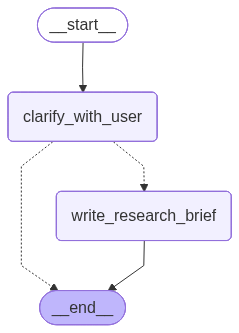

In [14]:
# Compile with in-memory checkpointer to test in notebook
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
scope = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(scope.get_graph(xray=True).draw_mermaid_png()))

In [15]:
# Run the workflow
from utils import format_messages
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1"}}
result = scope.invoke({"messages": [HumanMessage(content="What is the best coffee shop in seattle.")]}, config=thread)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on quality, atmosphere,    │
│ popularity, or another factor? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [16]:
human_answer = "quality and atmosphere are most important to me."
result = scope.invoke({"messages": [HumanMessage(content=human_answer)]}, config=thread)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on quality, atmosphere,    │
│ popularity, or another factor? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ quality and atmosphere are most important to me.                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying that quality and atmosphere are your top priorities for finding the best coffee shop   │
│ in Seattle. I now have enough information to begin researching and will focus on coffee shops in Seattle that   │
│ excel in both coffee quality and ambiance. I will now start the research process.                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [17]:
from rich.markdown import Markdown
Markdown(result["research_brief"])

I want to identify the best coffee shop in Seattle, with a primary focus on coffee quality and atmosphere, as these
are my top priorities. Please research and compare Seattle coffee shops based on the quality of their coffee       
(considering factors such as bean sourcing, roasting methods, brewing techniques, and taste) and the overall       
atmosphere (including ambiance, decor, comfort, and vibe). I have not specified a particular neighborhood, so      
consider the entire city of Seattle. Other factors such as price, food offerings, or popularity should only be     
considered if they are relevant to quality or atmosphere, but are not primary concerns unless they directly impact 
those two dimensions. Please prioritize information from official coffee shop websites, reputable review platforms 
(such as Google Reviews or Yelp), and respected local publications. If possible, provide direct links to these     
sources.

In [18]:
result

{'messages': [HumanMessage(content='What is the best coffee shop in seattle.', additional_kwargs={}, response_metadata={}, id='608873d4-89ab-4c28-9e14-67882d64c9e2'),
  AIMessage(content="Could you clarify what you mean by 'best'? Are you looking for the best coffee based on quality, atmosphere, popularity, or another factor? Also, are you interested in a specific neighborhood in Seattle or the city as a whole?", additional_kwargs={}, response_metadata={}, id='1dcdaefc-7618-4600-b61b-8ae288851e6f'),
  HumanMessage(content='quality and atmosphere are most important to me.', additional_kwargs={}, response_metadata={}, id='94869127-d392-4192-bc10-950ebf3a8ec1'),
  AIMessage(content='Thank you for clarifying that quality and atmosphere are your top priorities for finding the best coffee shop in Seattle. I now have enough information to begin researching and will focus on coffee shops in Seattle that excel in both coffee quality and ambiance. I will now start the research process.', additio